In [11]:
# 6B: CLASSIFICATION MODEL
import seaborn as sns
import numpy as np
from sklearn.model_selection import KFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt


In [12]:
iris = sns.load_dataset('iris')

In [13]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [14]:

X = iris.drop('species', axis=1)
Y = iris['species']


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


===== Fold 1 =====
Train Accuracy: 0.9583333333333334
Test Accuracy: 0.9666666666666667


C:\Users\shiv\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


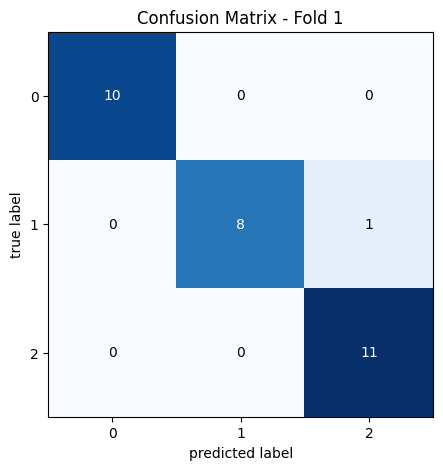


Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30


===== Fold 2 =====
Train Accuracy: 0.95
Test Accuracy: 0.9666666666666667


C:\Users\shiv\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


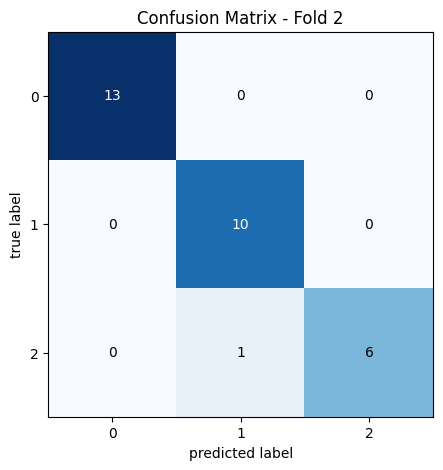


Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.86      0.92         7

    accuracy                           0.97        30
   macro avg       0.97      0.95      0.96        30
weighted avg       0.97      0.97      0.97        30


===== Fold 3 =====
Train Accuracy: 0.975
Test Accuracy: 0.9333333333333333


C:\Users\shiv\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


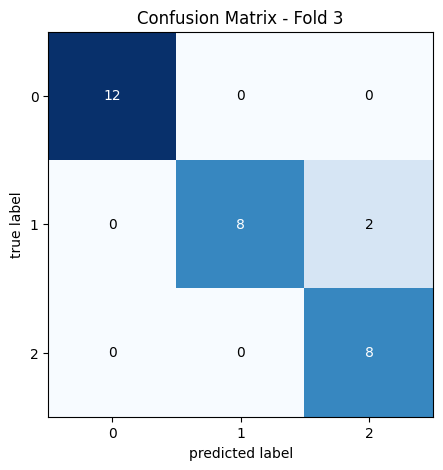


Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       1.00      0.80      0.89        10
   virginica       0.80      1.00      0.89         8

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.95      0.93      0.93        30


===== Fold 4 =====
Train Accuracy: 0.9666666666666667
Test Accuracy: 0.9333333333333333


C:\Users\shiv\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


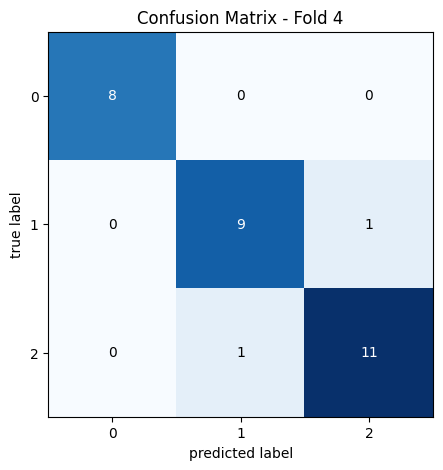


Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.90      0.90      0.90        10
   virginica       0.92      0.92      0.92        12

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.93      0.93      0.93        30


===== Fold 5 =====
Train Accuracy: 0.9666666666666667
Test Accuracy: 0.9666666666666667


C:\Users\shiv\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


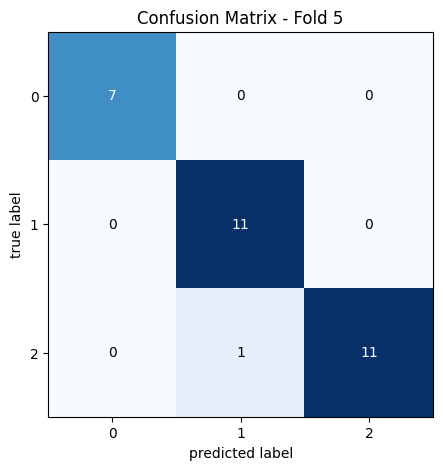


Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       0.92      1.00      0.96        11
   virginica       1.00      0.92      0.96        12

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Average Train Accuracy: 0.9633333333333333
Average Test Accuracy: 0.9533333333333334


In [16]:

# K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_acc_list = []
test_acc_list = []

for fold, (train_index, test_index) in enumerate(kf.split(X_scaled)):
    print(f"\n===== Fold {fold+1} =====")

    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]

    # Model
    clsModel = MLPClassifier(hidden_layer_sizes=(34,22),
                             activation='relu',
                             solver='sgd',
                             max_iter=1000,
                             random_state=42)

    
    clsModel.fit(X_train, Y_train)

    Y_trainPred = clsModel.predict(X_train)
    Y_testPred = clsModel.predict(X_test)

   
    train_acc = accuracy_score(Y_train, Y_trainPred)
    test_acc = accuracy_score(Y_test, Y_testPred)

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)


    cm = confusion_matrix(Y_test, Y_testPred)
    
    plot_confusion_matrix(conf_mat=cm, figsize=(5,5))
    plt.title(f"Confusion Matrix - Fold {fold+1}")
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(Y_test, Y_testPred))

# Average Accuracy
print("\n==============================")
print("Average Train Accuracy:", np.mean(train_acc_list))
print("Average Test Accuracy:", np.mean(test_acc_list))